# Physics-Informed Optical AI Verifier - Standalone Notebook

One notebook. No external `receiver` package. No imports from local modules.

**Goal:** simulate or load two intensity traces, run TDGSA phase retrieval, refine with a Torch physics-informed loss, and produce a trusted verification report.

This notebook focuses on measurement, physics consistency, numerical stability, and reproducibility.


device = cpu


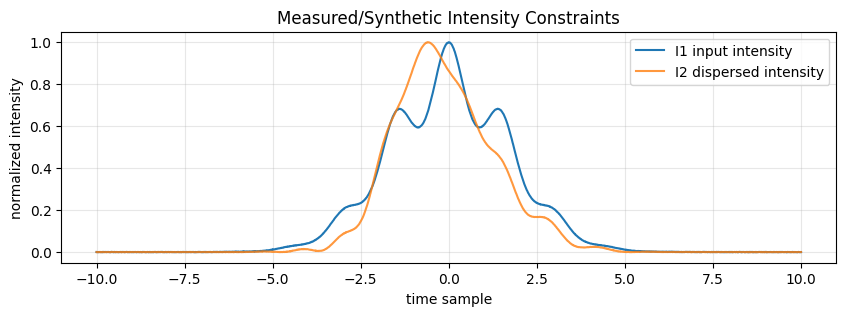

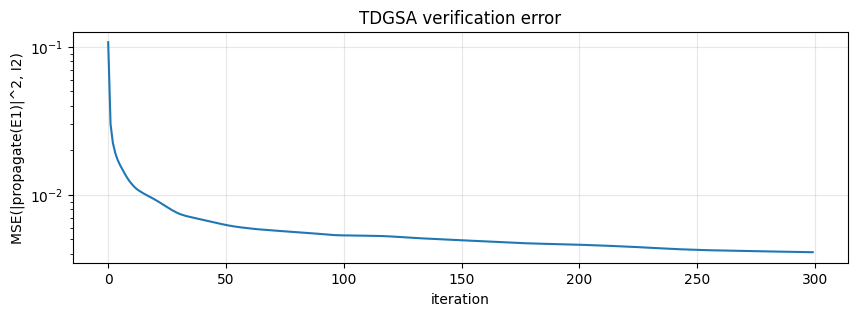

final total loss: 0.003927986137568951
final intensity loss: 0.0009879705030471087


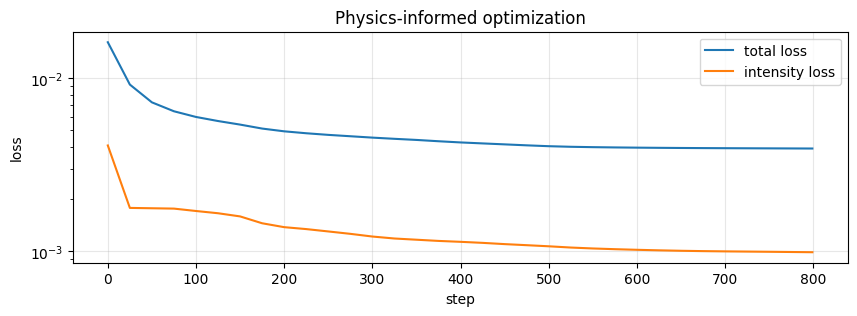


Physics Verification Report
---------------------------
intensity_mse               : 9.878534e-04
intensity_corr              : 9.959394e-01
energy_error                : 1.682339e-07
phase_smoothness            : 1.784381e+00
group_delay_smoothness      : 4.095575e+00
tdgsa_final_error           : 4.094354e-03
final_pinn_loss             : 3.927986e-03
STATUS: CHECK
feature vector: [9.8785339e-04 4.0606260e-03 1.6823385e-07 1.7843806e+00 4.0955753e+00
 4.0943539e-03 3.9279861e-03]
untrained AI verifier score: 0.48363804817199707 (placeholder; train later)


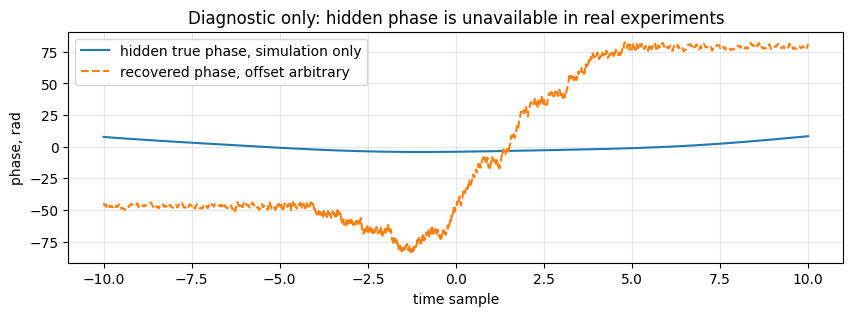

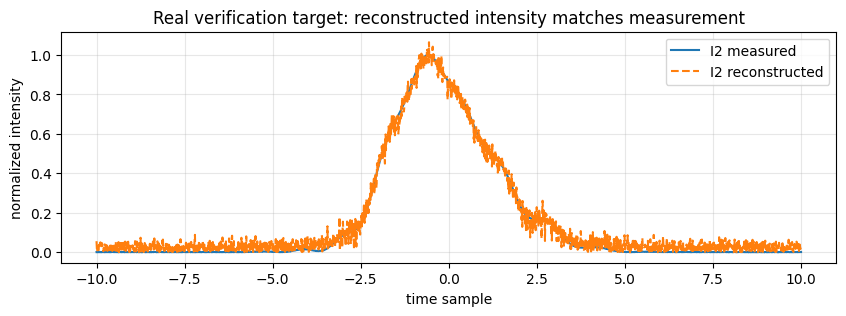


REAL MEASUREMENT PLAN

1. Split the optical pulse into two paths.
2. Path A: measure low-dispersion/input intensity I1 with photodiode + oscilloscope.
3. Path B: send through a known dispersive element, then measure I2.
4. Record sampling rate, time step, fiber length, dispersion beta2 or D, wavelength band.
5. Normalize traces: subtract dark offset, clip negatives, divide by max or total energy.
6. Resample I1 and I2 onto the same number of points.
7. Replace I1_meas and I2_meas in this notebook with real torch tensors.
8. Run TDGSA, then physics-informed refinement.
9. Judge success with intensity consistency, energy consistency, restart stability, and noise robustness.

Do not claim exact phase truth unless you have an independent phase measurement.



In [1]:
# ============================================================
# Physics-Informed Optical AI Verifier - Standalone Notebook
# One notebook, no package imports
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except Exception as e:
    raise RuntimeError("Install PyTorch first: pip install torch") from e

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)


def normalize_intensity(I, eps=1e-12):
    """Baseline-safe intensity normalization."""
    I = torch.clamp(I, min=0.0)
    return I / (torch.max(I) + eps)


def make_dispersion_operator(N, dt, beta2=-0.85, L=1.0, device="cpu"):
    """Frequency-domain quadratic dispersion operator."""
    freq = torch.fft.fftfreq(N, d=dt).to(device)
    omega = 2 * math.pi * freq
    H = torch.exp(-0.5j * beta2 * L * omega**2)
    return H, omega


def propagate(E, H):
    """Forward dispersive propagation."""
    return torch.fft.ifft(torch.fft.fft(E) * H)


def backpropagate(E, H):
    """Inverse dispersive propagation for unit-magnitude all-pass H."""
    return torch.fft.ifft(torch.fft.fft(E) * torch.conj(H))


def synthetic_trace(N=2048, beta2=-0.85, L=1.0, noise=0.002, device="cpu"):
    """Generate synthetic I1/I2 intensity traces with hidden phase for diagnostics only."""
    t = torch.linspace(-10, 10, N, device=device)
    dt = float(t[1] - t[0])
    H, omega = make_dispersion_operator(N, dt, beta2=beta2, L=L, device=device)

    amp_true = torch.exp(-0.5 * (t / 2.4)**2) * (1.0 + 0.10 * torch.cos(4.0 * t))
    amp_true = torch.clamp(amp_true, min=0.0)
    phi_true = 0.12 * t**2 + 0.45 * torch.sin(0.7 * t)
    E1_true = amp_true * torch.exp(1j * phi_true)
    E2_true = propagate(E1_true, H)

    I1 = torch.abs(E1_true)**2 + noise * torch.rand(N, device=device)
    I2 = torch.abs(E2_true)**2 + noise * torch.rand(N, device=device)
    I1 = normalize_intensity(I1)
    I2 = normalize_intensity(I2)
    return t, I1, I2, H, phi_true, E1_true, E2_true


def tdgsa(I1, I2, H, n_iter=300, seed=0):
    """Time-domain Gerchberg-Saxton alternating projection using two intensity constraints."""
    torch.manual_seed(seed)
    phase = 2 * math.pi * torch.rand_like(I1) - math.pi
    E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * phase)
    errors = []
    for _ in range(n_iter):
        E2 = propagate(E1, H)
        I2_pred = torch.abs(E2)**2
        errors.append(torch.mean((I2_pred - I2)**2).detach())
        E2 = torch.sqrt(I2 + 1e-12) * torch.exp(1j * torch.angle(E2))
        E1_back = backpropagate(E2, H)
        E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * torch.angle(E1_back))
    return E1, torch.stack(errors)


def refine_phase(I1, I2, H, phase_init, n_steps=800, lr=0.025,
                 w_energy=0.001, w_phase=0.0005, w_gd=0.0005):
    """Torch optimization over phase with physics-informed loss terms."""
    N = I1.numel()
    phase = torch.nn.Parameter(phase_init.detach().clone())
    opt = torch.optim.Adam([phase], lr=lr)
    history = []
    for step in range(n_steps):
        E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * phase)
        E2 = propagate(E1, H)
        I2_pred = torch.abs(E2)**2
        intensity_loss = torch.mean((I2_pred - I2)**2)
        energy_loss = (torch.sum(torch.abs(E1)**2) - torch.sum(torch.abs(E2)**2)).pow(2) / (N**2)
        phase_smooth_loss = torch.mean((phase[1:] - phase[:-1])**2)
        group_delay_smooth_loss = torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)
        loss = intensity_loss + w_energy*energy_loss + w_phase*phase_smooth_loss + w_gd*group_delay_smooth_loss
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % 25 == 0 or step == n_steps - 1:
            history.append([step, float(loss.detach().cpu()), float(intensity_loss.detach().cpu()),
                            float(energy_loss.detach().cpu()), float(phase_smooth_loss.detach().cpu()),
                            float(group_delay_smooth_loss.detach().cpu())])
    return phase.detach(), np.array(history)


def safe_corrcoef(a, b, eps=1e-12):
    """Correlation that avoids NaN for nearly constant traces."""
    a = a - torch.mean(a)
    b = b - torch.mean(b)
    denom = torch.sqrt(torch.sum(a*a) * torch.sum(b*b)) + eps
    return torch.sum(a*b) / denom


def verification_metrics(I1, I2, H, phase, tdgsa_errors=None, final_loss=None):
    """Compute physics-based verification metrics; no hidden phase required."""
    with torch.no_grad():
        E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * phase)
        E2 = propagate(E1, H)
        I2_rec = torch.abs(E2)**2
        intensity_mse = torch.mean((I2_rec - I2)**2)
        intensity_corr = safe_corrcoef(I2_rec, I2)
        energy_error = torch.abs(torch.sum(torch.abs(E1)**2) - torch.sum(torch.abs(E2)**2)) / (torch.sum(torch.abs(E1)**2) + 1e-12)
        phase_smoothness = torch.mean((phase[1:] - phase[:-1])**2)
        group_delay_smoothness = torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)
        tdgsa_final_error = tdgsa_errors[-1] if tdgsa_errors is not None else torch.tensor(float('nan'), device=I1.device)
        final_pinn_loss = torch.tensor(final_loss if final_loss is not None else float('nan'), device=I1.device)
    return {
        'intensity_mse': float(intensity_mse.cpu()),
        'intensity_corr': float(intensity_corr.cpu()),
        'energy_error': float(energy_error.cpu()),
        'phase_smoothness': float(phase_smoothness.cpu()),
        'group_delay_smoothness': float(group_delay_smoothness.cpu()),
        'tdgsa_final_error': float(tdgsa_final_error.cpu()),
        'final_pinn_loss': float(final_pinn_loss.cpu()),
    }, I2_rec.detach()


def pass_check_fail(metrics):
    """Rule-based verifier. Tune thresholds per experiment."""
    good = (metrics['intensity_mse'] < 5e-4 and metrics['intensity_corr'] > 0.98 and
            metrics['energy_error'] < 1e-5 and metrics['phase_smoothness'] < 2.0)
    check = (metrics['intensity_mse'] < 2e-3 and metrics['intensity_corr'] > 0.93 and
             metrics['energy_error'] < 1e-3)
    if good:
        return 'PASS'
    if check:
        return 'CHECK'
    return 'FAIL'


def feature_vector(metrics):
    """Make a numeric feature vector for an AI verifier."""
    return np.array([metrics['intensity_mse'], 1.0 - metrics['intensity_corr'], metrics['energy_error'],
                     metrics['phase_smoothness'], metrics['group_delay_smoothness'],
                     metrics['tdgsa_final_error'], metrics['final_pinn_loss']], dtype=np.float32)


class TinyVerifier(torch.nn.Module):
    """Tiny MLP scaffold: train later on many examples/restarts."""
    def __init__(self, n_features=7):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_features, 16), torch.nn.ReLU(),
            torch.nn.Linear(16, 8), torch.nn.ReLU(),
            torch.nn.Linear(8, 1),
        )
    def forward(self, x):
        return self.net(x)


def np_unwrap_center(x):
    """Convert tensor/array to unwrapped, mean-centered NumPy array."""
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    y = np.unwrap(x)
    return y - np.mean(y)


# -----------------------------
# Generate synthetic measurement data
# -----------------------------
N = 2048
beta2 = -0.85
L = 1.0

t, I1_meas, I2_meas, H, phi_true, E1_true, E2_true = synthetic_trace(
    N=N, beta2=beta2, L=L, noise=0.002, device=device
)

plt.figure(figsize=(10, 3))
plt.plot(t.detach().cpu().numpy(), I1_meas.detach().cpu().numpy(), label='I1 input intensity')
plt.plot(t.detach().cpu().numpy(), I2_meas.detach().cpu().numpy(), label='I2 dispersed intensity', alpha=0.8)
plt.title('Measured/Synthetic Intensity Constraints')
plt.xlabel('time sample')
plt.ylabel('normalized intensity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# TDGSA baseline
# -----------------------------
E1_gs, gs_errors = tdgsa(I1_meas, I2_meas, H, n_iter=300, seed=2)

plt.figure(figsize=(10, 3))
plt.semilogy(gs_errors.detach().cpu().numpy())
plt.title('TDGSA verification error')
plt.xlabel('iteration')
plt.ylabel('MSE(|propagate(E1)|^2, I2)')
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# Torch physics-informed refinement
# -----------------------------
phase_init = torch.angle(E1_gs)
phase_rec, loss_history = refine_phase(I1_meas, I2_meas, H, phase_init, n_steps=800, lr=0.025)

print('final total loss:', loss_history[-1, 1])
print('final intensity loss:', loss_history[-1, 2])

plt.figure(figsize=(10, 3))
plt.semilogy(loss_history[:, 0], loss_history[:, 1], label='total loss')
plt.semilogy(loss_history[:, 0], loss_history[:, 2], label='intensity loss')
plt.title('Physics-informed optimization')
plt.xlabel('step')
plt.ylabel('loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Verification report
# -----------------------------
metrics, I2_rec = verification_metrics(I1_meas, I2_meas, H, phase_rec, tdgsa_errors=gs_errors, final_loss=loss_history[-1, 1])
status = pass_check_fail(metrics)
features = feature_vector(metrics)

print('\nPhysics Verification Report')
print('---------------------------')
for k, v in metrics.items():
    print(f'{k:28s}: {v:.6e}')
print('STATUS:', status)
print('feature vector:', features)

verifier = TinyVerifier(n_features=len(features)).to(device)
with torch.no_grad():
    x = torch.tensor(features, device=device).view(1, -1)
    raw_score = torch.sigmoid(verifier(x)).item()
print('untrained AI verifier score:', raw_score, '(placeholder; train later)')

# -----------------------------
# Diagnostics
# -----------------------------
t_np = t.detach().cpu().numpy()
phase_rec_aligned = np_unwrap_center(phase_rec)
phase_true_aligned = np_unwrap_center(phi_true)

plt.figure(figsize=(10, 3))
plt.plot(t_np, phase_true_aligned, label='hidden true phase, simulation only')
plt.plot(t_np, phase_rec_aligned, '--', label='recovered phase, offset arbitrary')
plt.title('Diagnostic only: hidden phase is unavailable in real experiments')
plt.xlabel('time sample')
plt.ylabel('phase, rad')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t_np, I2_meas.detach().cpu().numpy(), label='I2 measured')
plt.plot(t_np, I2_rec.detach().cpu().numpy(), '--', label='I2 reconstructed')
plt.title('Real verification target: reconstructed intensity matches measurement')
plt.xlabel('time sample')
plt.ylabel('normalized intensity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('''
REAL MEASUREMENT PLAN

1. Split the optical pulse into two paths.
2. Path A: measure low-dispersion/input intensity I1 with photodiode + oscilloscope.
3. Path B: send through a known dispersive element, then measure I2.
4. Record sampling rate, time step, fiber length, dispersion beta2 or D, wavelength band.
5. Normalize traces: subtract dark offset, clip negatives, divide by max or total energy.
6. Resample I1 and I2 onto the same number of points.
7. Replace I1_meas and I2_meas in this notebook with real torch tensors.
8. Run TDGSA, then physics-informed refinement.
9. Judge success with intensity consistency, energy consistency, restart stability, and noise robustness.

Do not claim exact phase truth unless you have an independent phase measurement.
''')


SymPy Physics and Mathematics Demonstration

Atomic Number = 1
Wavefunction


Function


Derivative


Logarithmic derivative


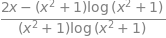

Complex exponential


Complex conjugate


Intensity



Atomic Number = 2
Wavefunction


Function


Derivative


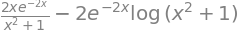

Logarithmic derivative


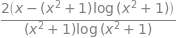

Complex exponential


Complex conjugate


Intensity



Atomic Number = 3
Wavefunction


Function


Derivative


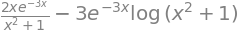

Logarithmic derivative


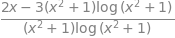

Complex exponential


Complex conjugate


Intensity



Atomic Number = 4
Wavefunction


Function


Derivative


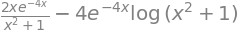

Logarithmic derivative


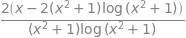

Complex exponential


Complex conjugate


Intensity



Atomic Number = 5
Wavefunction


Function


Derivative


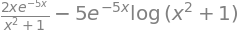

Logarithmic derivative


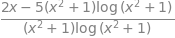

Complex exponential


Complex conjugate


Intensity



Atomic Number = 6
Wavefunction


Function


Derivative


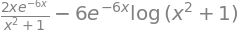

Logarithmic derivative


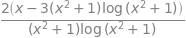

Complex exponential


Complex conjugate


Intensity



Atomic Number = 7
Wavefunction


Function


Derivative


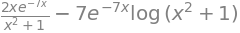

Logarithmic derivative


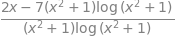

Complex exponential


Complex conjugate


Intensity



Atomic Number = 8
Wavefunction


Function


Derivative


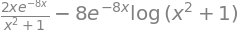

Logarithmic derivative


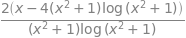

Complex exponential


Complex conjugate


Intensity



Atomic Number = 9
Wavefunction


Function


Derivative


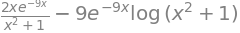

Logarithmic derivative


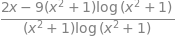

Complex exponential


Complex conjugate


Intensity



Atomic Number = 10
Wavefunction


Function


Derivative


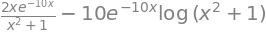

Logarithmic derivative


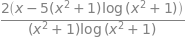

Complex exponential


Complex conjugate


Intensity


In [3]:
import sympy as sp
from IPython.display import display

# Pretty printing
sp.init_printing(use_unicode=True)

# Symbols
x, t, omega = sp.symbols('x t omega', real=True)
Z = sp.symbols('Z', integer=True, positive=True)
I = sp.I

print("="*60)
print("SymPy Physics and Mathematics Demonstration")
print("="*60)

for atomic_number in range(1, 11):

    print(f"\nAtomic Number = {atomic_number}")

    # Example exponential decay
    psi = sp.exp(-atomic_number*x)

    # Logarithm
    f = psi * sp.log(1 + x**2)

    # Derivative
    df = sp.diff(f, x)

    # Logarithmic differentiation
    dlog = sp.simplify(sp.diff(sp.log(f), x))

    # Complex wave
    E = sp.exp(I*omega*t)

    # Complex conjugate
    Ec = sp.conjugate(E)

    # Intensity
    intensity = sp.expand_complex(E*Ec)

    print("Wavefunction")
    display(psi)

    print("Function")
    display(f)

    print("Derivative")
    display(df)

    print("Logarithmic derivative")
    display(dlog)

    print("Complex exponential")
    display(E)

    print("Complex conjugate")
    display(Ec)

    print("Intensity")
    display(intensity)

In [4]:
# ==========================================================
# Cell 1
# Scientific Mathematics Toolkit
# ==========================================================

import sympy as sp
from IPython.display import display

sp.init_printing(use_unicode=True)

x, t = sp.symbols("x t", real=True)
k = sp.symbols("k", positive=True)
omega = sp.symbols("omega", real=True)
I = sp.I

print("SymPy initialized.")

SymPy initialized.


Unit step:


Dirac delta:


Sifting property:


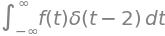

Ideal symbolic clock signal:


Complex exponential wave:


Intensity from complex conjugate:


Taylor series for exp(x):


Taylor series for sin(x):


In [5]:
# ==========================================================
# Cell 2
# Step functions, Dirac delta, clock signals, Taylor series
# ==========================================================

import sympy as sp
from IPython.display import display

sp.init_printing(use_unicode=True)

t, x, omega, T = sp.symbols("t x omega T", real=True, positive=True)
n = sp.symbols("n", integer=True)
I = sp.I

# Unit step and Dirac delta
u = sp.Heaviside(t)
delta = sp.DiracDelta(t)

print("Unit step:")
display(u)

print("Dirac delta:")
display(delta)

print("Sifting property:")
f = sp.Function("f")
display(sp.Integral(f(t) * sp.DiracDelta(t - 2), (t, -sp.oo, sp.oo)))
display(sp.simplify(sp.integrate(sp.sin(t) * sp.DiracDelta(t - 2), (t, -sp.oo, sp.oo))))

# Clock-like square wave using sign(sin)
clock = sp.sign(sp.sin(omega*t))
print("Ideal symbolic clock signal:")
display(clock)

# Complex EM-style wave
E = sp.exp(I * omega * t)
print("Complex exponential wave:")
display(E)

print("Intensity from complex conjugate:")
display(sp.simplify(E * sp.conjugate(E)))

# Taylor series
print("Taylor series for exp(x):")
display(sp.series(sp.exp(x), x, 0, 6))

print("Taylor series for sin(x):")
display(sp.series(sp.sin(x), x, 0, 7))

1D Dirac delta sampling:


Loop over sample points:
sample at x = -3


sample at x = -1


sample at x = 0


sample at x = 1


sample at x = 3


3D Cartesian delta sampling:


Spherical volume element:


Radial delta source concept:


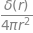

In [6]:
import sympy as sp
from IPython.display import display

sp.init_printing(use_unicode=True)

x, y, z, r, theta, phi = sp.symbols("x y z r theta phi", real=True)
a = sp.symbols("a", real=True)

# -----------------------------
# 1D sifting property
# -----------------------------
f = sp.sin(x) + x**2

expr_1d = sp.integrate(f * sp.DiracDelta(x - 3), (x, -sp.oo, sp.oo))

print("1D Dirac delta sampling:")
display(expr_1d)

# -----------------------------
# Loop over zeros / sample points
# -----------------------------
sample_points = [-3, -1, 0, 1, 3]

print("Loop over sample points:")
for p in sample_points:
    result = sp.integrate(f * sp.DiracDelta(x - p), (x, -sp.oo, sp.oo))
    print("sample at x =", p)
    display(result)

# -----------------------------
# 3D Cartesian delta
# -----------------------------
F = x**2 + y**2 + z**2 + sp.sin(x)

delta3_cart = sp.DiracDelta(x) * sp.DiracDelta(y) * sp.DiracDelta(z)

expr_3d = sp.integrate(
    F * delta3_cart,
    (x, -sp.oo, sp.oo),
    (y, -sp.oo, sp.oo),
    (z, -sp.oo, sp.oo)
)

print("3D Cartesian delta sampling:")
display(expr_3d)

# -----------------------------
# Spherical volume element idea
# -----------------------------
volume_element_spherical = r**2 * sp.sin(theta)

print("Spherical volume element:")
display(volume_element_spherical)

print("Radial delta source concept:")
display(sp.DiracDelta(r) / (4 * sp.pi * r**2))